In [1]:
import sys
import json
import warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import torch
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

PROJECT_ROOT = Path().resolve().parent  # up one level from explainability/
sys.path.insert(0, str(PROJECT_ROOT))
print(f"PyTorch {torch.__version__}, CUDA: {torch.cuda.is_available()}")

PyTorch 2.11.0+cpu, CUDA: False


In [2]:
DATASET = "both"           # "dataset1", "dataset2", or "both"
N_SAMPLES = 200
TOP_N_WORDS = 20
LLM_MODEL = "qwen2.5:32b"
N_LLM_SAMPLES = 5

DATASET_DIRS = {
    "dataset1": PROJECT_ROOT / "outputs" / "dataset1_20260427_173242",
    "dataset2": PROJECT_ROOT / "outputs" / "dataset2_20260428_003133",
}
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

MAX_LEN = 128
LABEL_NAMES = {0: "REAL", 1: "FAKE"}

SKIP_TOKENS = {
    "[cls]", "[sep]", "[pad]",
    "the", "a", "an", "is", "was", "to", "of", "and", "in", "that",
    "for", "it", "with", "as", "on", "at", "by", "from", "this", "be",
    "are", "were", "has", "had", "have", "its", "but", "not", "or",
    "so", "he", "she", "they", "we", "his", "her", "their", "our",
    "who", "which", "what", "when", "how", "if", "do", "did", "will",
    "also", "would", "could", "should", "more", "than", "up", "been",
    "about", "after", "before", "said", "says", "say", "one", "two",
    "new", "just", "all", "no", "into", "out", "there", "over",
    "can", "then", "them", "these", "those", "him", "any",
}

In [3]:
def check_lfs_pointer(model_dir):
    weights = model_dir / "model.safetensors"
    if not weights.exists():
        raise FileNotFoundError(f"Run: git lfs pull  (no weights in {model_dir})")
    if weights.stat().st_size < 10_000:
        raise RuntimeError("model.safetensors is a Git LFS pointer. Run: git lfs pull")


def load_model(model_dir):
    check_lfs_pointer(model_dir)
    print(f"loading {model_dir.name}...")
    tokenizer = AutoTokenizer.from_pretrained(str(model_dir))
    model = AutoModelForSequenceClassification.from_pretrained(
        str(model_dir), attn_implementation="eager"
    )
    device = (
        torch.device("cuda") if torch.cuda.is_available()
        else torch.device("mps") if torch.backends.mps.is_available()
        else torch.device("cpu")
    )
    model.to(device).eval()
    print(f"  device: {device}")
    return model, tokenizer, device


def load_eval_data(dataset_key):
    if dataset_key == "dataset1":
        from preprocessing import test, evaluation
        return pd.concat([test, evaluation], ignore_index=True)
    from preprocessing import dataset_two_test, dataset_two_validation
    return pd.concat([dataset_two_test, dataset_two_validation], ignore_index=True)


def merge_subwords(tokens, scores, mask):
    word_scores = []
    current_word, current_max = None, 0.0
    for tok, score, m in zip(tokens, scores, mask):
        if not m:
            break
        if tok in ("[CLS]", "[SEP]"):
            if current_word:
                word_scores.append((current_word, current_max))
            current_word, current_max = None, 0.0
            continue
        if tok.startswith("##"):
            current_max = max(current_max, score.item())
        else:
            if current_word:
                word_scores.append((current_word, current_max))
            current_word, current_max = tok, score.item()
    if current_word:
        word_scores.append((current_word, current_max))
    return sorted(word_scores, key=lambda x: -x[1])


@torch.enable_grad()
def get_saliency(title, text, model, tokenizer, device):
    enc = tokenizer(
        title, text,
        max_length=MAX_LEN, padding="max_length",
        truncation=True, return_attention_mask=True, return_tensors="pt",
    )
    input_ids = enc["input_ids"].to(device)
    attention_mask = enc["attention_mask"].to(device)

    embeddings = model.bert.embeddings(input_ids)
    embeddings.retain_grad()
    outputs = model(inputs_embeds=embeddings, attention_mask=attention_mask)

    pred = outputs.logits.argmax(dim=-1).item()
    conf = torch.softmax(outputs.logits, dim=-1)[0, pred].item()
    outputs.logits[0, pred].backward()

    grad_norms = embeddings.grad.norm(dim=-1).squeeze(0).detach().cpu()
    tokens = tokenizer.convert_ids_to_tokens(input_ids.squeeze(0).cpu())
    mask = attention_mask.squeeze(0).cpu().bool()
    return pred, conf, merge_subwords(tokens, grad_norms, mask)


def run_saliency(df, model, tokenizer, device, n=200):
    sample = df.sample(n=min(n, len(df)), random_state=42)
    fake_acc, real_acc = defaultdict(list), defaultdict(list)
    preds, labels = [], []

    for i, (_, row) in enumerate(sample.iterrows()):
        try:
            pred, conf, word_scores = get_saliency(
                str(row.get("title", "")), str(row.get("text", "")),
                model, tokenizer, device
            )
        except Exception as e:
            warnings.warn(f"skipping row {i}: {e}")
            continue
        preds.append(pred)
        labels.append(int(row["label"]))
        bucket = fake_acc if pred == 1 else real_acc
        for word, score in word_scores:
            w = word.lower()
            if w not in SKIP_TOKENS and len(w) > 2 and w.isalpha():
                bucket[w].append(score)
        if (i + 1) % 50 == 0:
            print(f"  {i + 1}/{len(sample)}")

    fake_words = {w: float(np.mean(v)) for w, v in fake_acc.items() if len(v) >= 2}
    real_words = {w: float(np.mean(v)) for w, v in real_acc.items() if len(v) >= 2}
    return fake_words, real_words, preds, labels

In [4]:
datasets = ["dataset1", "dataset2"] if DATASET == "both" else [DATASET]
results = {}

for ds in datasets:
    print(f"\n{ds}")
    model, tokenizer, device = load_model(DATASET_DIRS[ds])
    df = load_eval_data(ds)
    print(f"  {len(df)} samples, running saliency on {min(N_SAMPLES, len(df))}...")
    fake_words, real_words, preds, labels = run_saliency(
        df, model, tokenizer, device, n=N_SAMPLES
    )
    results[ds] = dict(
        fake_words=fake_words, real_words=real_words,
        preds=preds, labels=labels,
        model=model, tokenizer=tokenizer, device=device, df=df
    )
    print(f"  {len(fake_words)} fake words, {len(real_words)} real words collected")


dataset1
loading dataset1_20260427_173242...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

  device: cpu


100%|██████████| 39.0M/39.0M [00:01<00:00, 34.1MB/s]

Extracting files...


...

100%|██████████| 92.1M/92.1M [00:02<00:00, 36.1MB/s]

Extracting files...


Path to dataset files: C:\Users\Kyle\.cache\kagglehub\datasets\saurabhshahane\fake-news-classification\versions\77
                                                  title  \
6118  three shocking reasons why hillary clinton is ...   
2203  oops trump hating dem senator caught in huge l...   
130   ellen degeneres cleverly uses finding dory to ...   
7126  trump just added white nationalist to his offi...   
2154   taliban attacks kill at least across afghanistan   
...                                                 ...   
7981  some lawmakers talk gun control after florida ...   
5218  trump expected to order temporary ban on refugees   
3995  united nations chief very worried by saudi leb...   
235   go ck yourselves larry wilmore slams ted cruz ...   
5183  mark hamill is back mocking trump by reading a...   

                                                   text  label  
6118  extreme positions on abortionhillary clinton p...      0  
2203  democratic senator claire mccaskill in b

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

  device: cpu
  24342 samples, running saliency on 200...
  50/200
  100/200
  150/200
  200/200
  1087 fake words, 1365 real words collected


## Evaluation Metrics

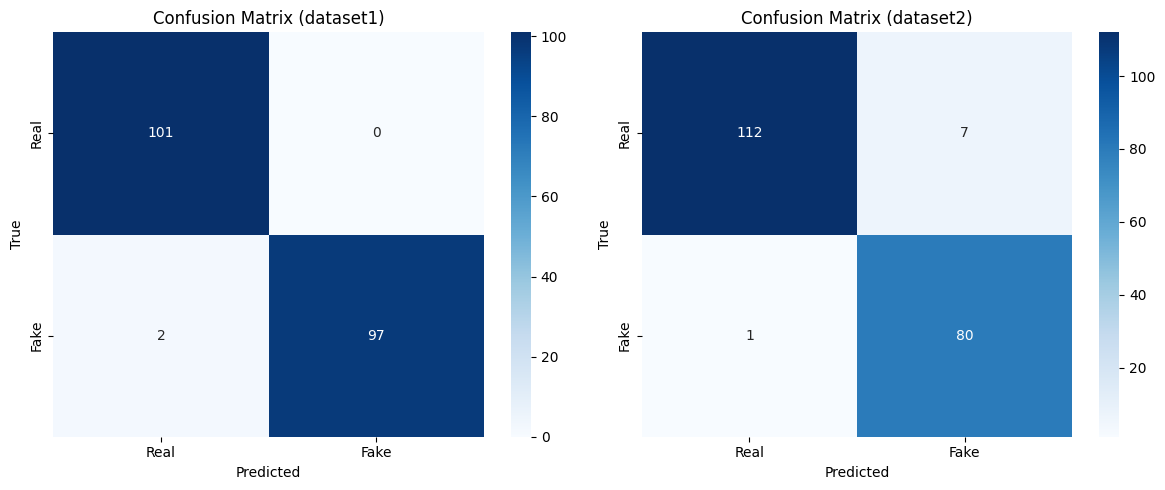

In [5]:
fig, axes = plt.subplots(1, len(datasets), figsize=(6 * len(datasets), 5))
if len(datasets) == 1:
    axes = [axes]
for ax, ds in zip(axes, datasets):
    r = results[ds]
    cm = confusion_matrix(r["labels"], r["preds"])
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=["Real", "Fake"], yticklabels=["Real", "Fake"], ax=ax
    )
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(f"Confusion Matrix ({ds})")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "confusion_matrices.png", dpi=150)
plt.show()

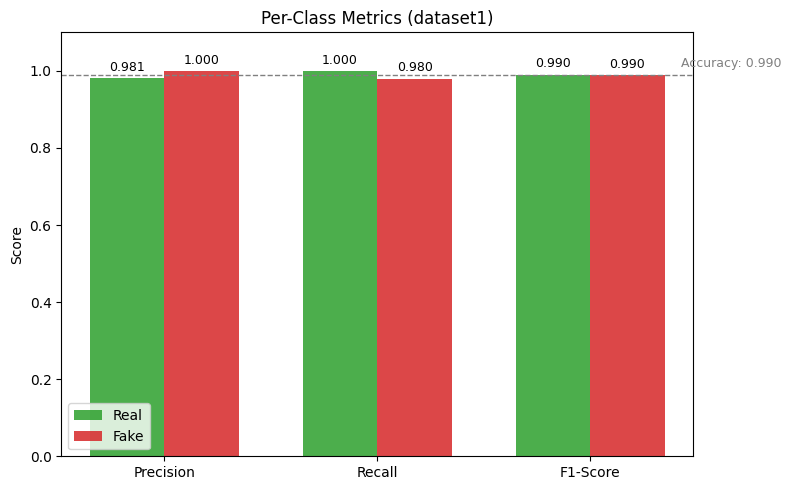

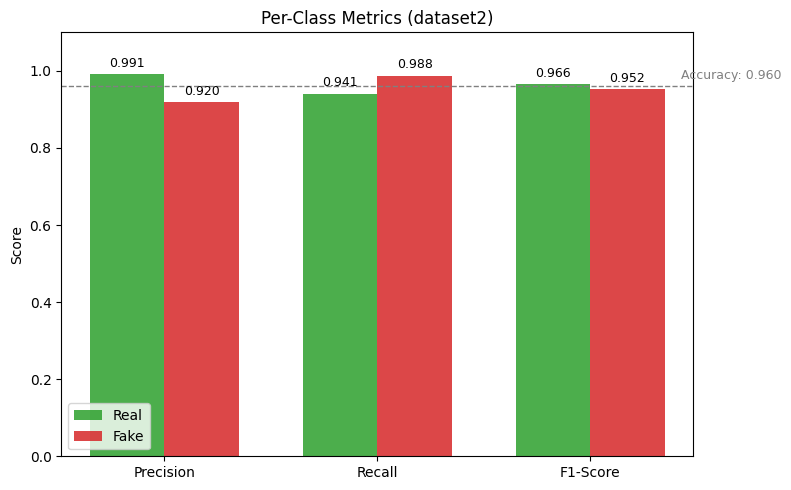

In [6]:
for ds in datasets:
    r = results[ds]
    report = classification_report(
        r["labels"], r["preds"], target_names=["Real", "Fake"], output_dict=True
    )
    metric_keys = ["precision", "recall", "f1-score"]
    x = np.arange(len(metric_keys))
    width = 0.35

    fig, ax = plt.subplots(figsize=(8, 5))
    br = ax.bar(x - width / 2, [report["Real"][m] for m in metric_keys],
                width, label="Real", color="#2ca02c", alpha=0.85)
    bf = ax.bar(x + width / 2, [report["Fake"][m] for m in metric_keys],
                width, label="Fake", color="#d62728", alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(["Precision", "Recall", "F1-Score"])
    ax.set_ylim(0, 1.1)
    ax.set_ylabel("Score")
    ax.set_title(f"Per-Class Metrics ({ds})")
    acc = report["accuracy"]
    ax.axhline(acc, color="gray", linestyle="--", linewidth=1)
    ax.text(len(metric_keys) - 0.1, acc + 0.02, f"Accuracy: {acc:.3f}",
            color="gray", fontsize=9, ha="right")
    ax.legend()
    for bar in list(br) + list(bf):
        h = bar.get_height()
        ax.annotate(f"{h:.3f}",
                    xy=(bar.get_x() + bar.get_width() / 2, h),
                    xytext=(0, 3), textcoords="offset points",
                    ha="center", va="bottom", fontsize=9)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"per_class_metrics_{ds}.png", dpi=150)
    plt.show()

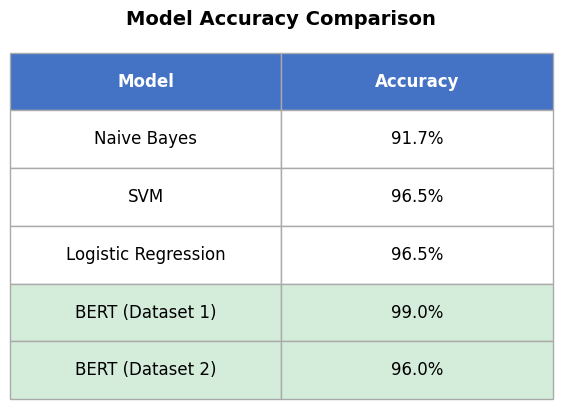

In [7]:
from preprocessing import read_train, read_test, clean_normalize_dataset

train_data = clean_normalize_dataset(read_train)
test_data = clean_normalize_dataset(read_test)
X_tr = (train_data["title"] + " " + train_data["text"]).values
y_tr = train_data["label"].values
X_te = (test_data["title"] + " " + test_data["text"]).values
y_te = test_data["label"].values

vec = TfidfVectorizer(max_features=5000, stop_words="english")
X_tr_vec = vec.fit_transform(X_tr)
X_te_vec = vec.transform(X_te)

table_rows = []
for name, clf in [
    ("Naive Bayes", MultinomialNB()),
    ("SVM", LinearSVC(max_iter=2000, random_state=1)),
    ("Logistic Regression", LogisticRegression(max_iter=1000, random_state=1)),
]:
    clf.fit(X_tr_vec, y_tr)
    table_rows.append([name, f"{accuracy_score(y_te, clf.predict(X_te_vec)):.1%}"])

for ds in datasets:
    r = results[ds]
    label = "Dataset 1" if "1" in ds else "Dataset 2"
    table_rows.append([f"BERT ({label})", f"{accuracy_score(r['labels'], r['preds']):.1%}"])

fig, ax = plt.subplots(figsize=(7, len(table_rows) * 0.6 + 1.5))
ax.axis("off")
t = ax.table(
    cellText=table_rows,
    colLabels=["Model", "Accuracy"],
    cellLoc="center", loc="center", bbox=[0, 0, 1, 1]
)
t.auto_set_font_size(False)
t.set_fontsize(12)
bert_start = len(table_rows) - len(datasets) + 1
for (row, col), cell in t.get_celld().items():
    if row == 0:
        cell.set_facecolor("#4472C4")
        cell.set_text_props(color="white", fontweight="bold")
    elif row >= bert_start:
        cell.set_facecolor("#d4edda")
    cell.set_edgecolor("#aaaaaa")
ax.set_title("Model Accuracy Comparison", pad=20, fontsize=14, fontweight="bold")
plt.savefig(FIGURES_DIR / "accuracy_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## Word Importance

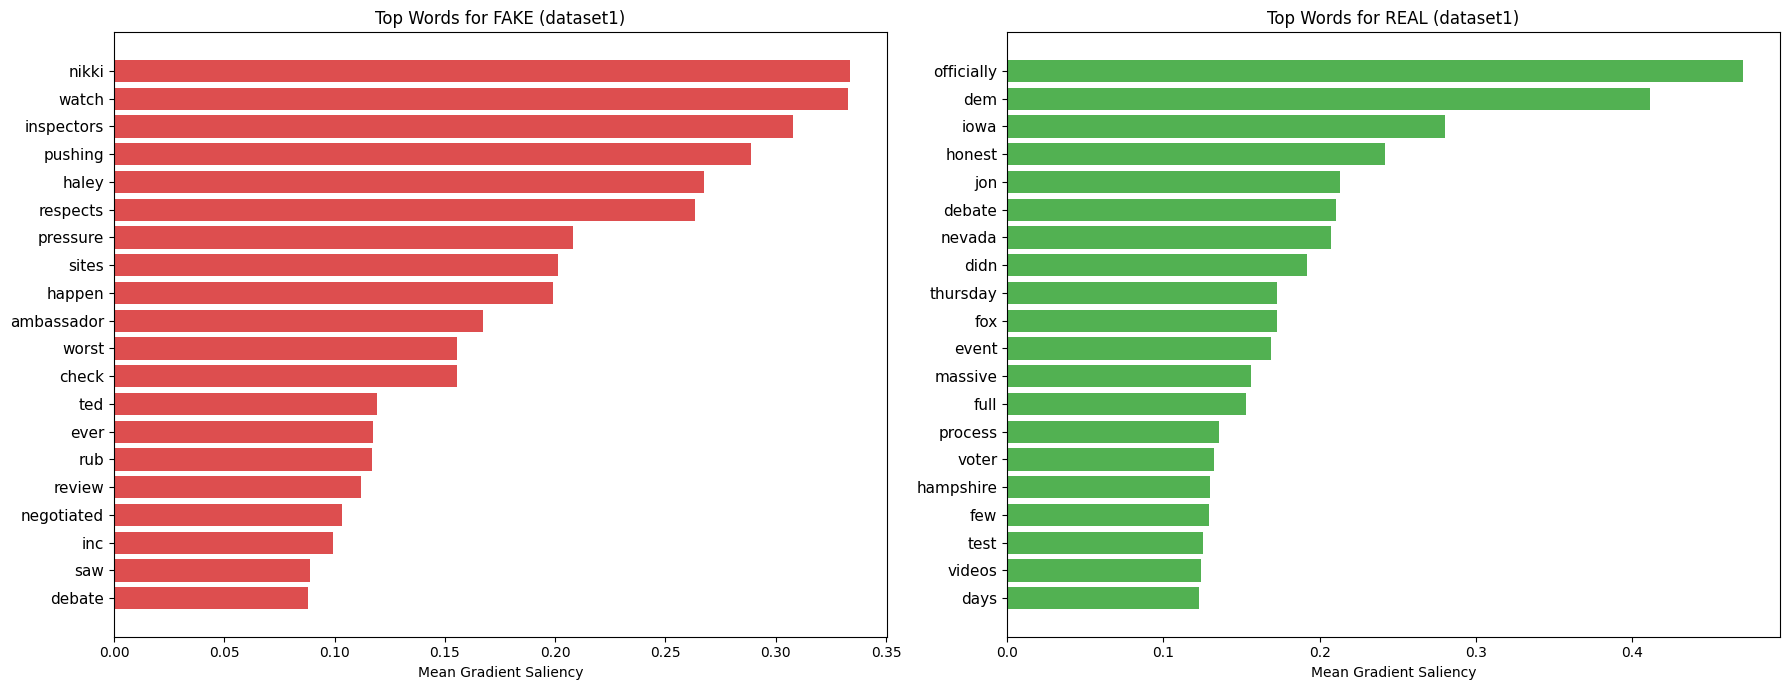

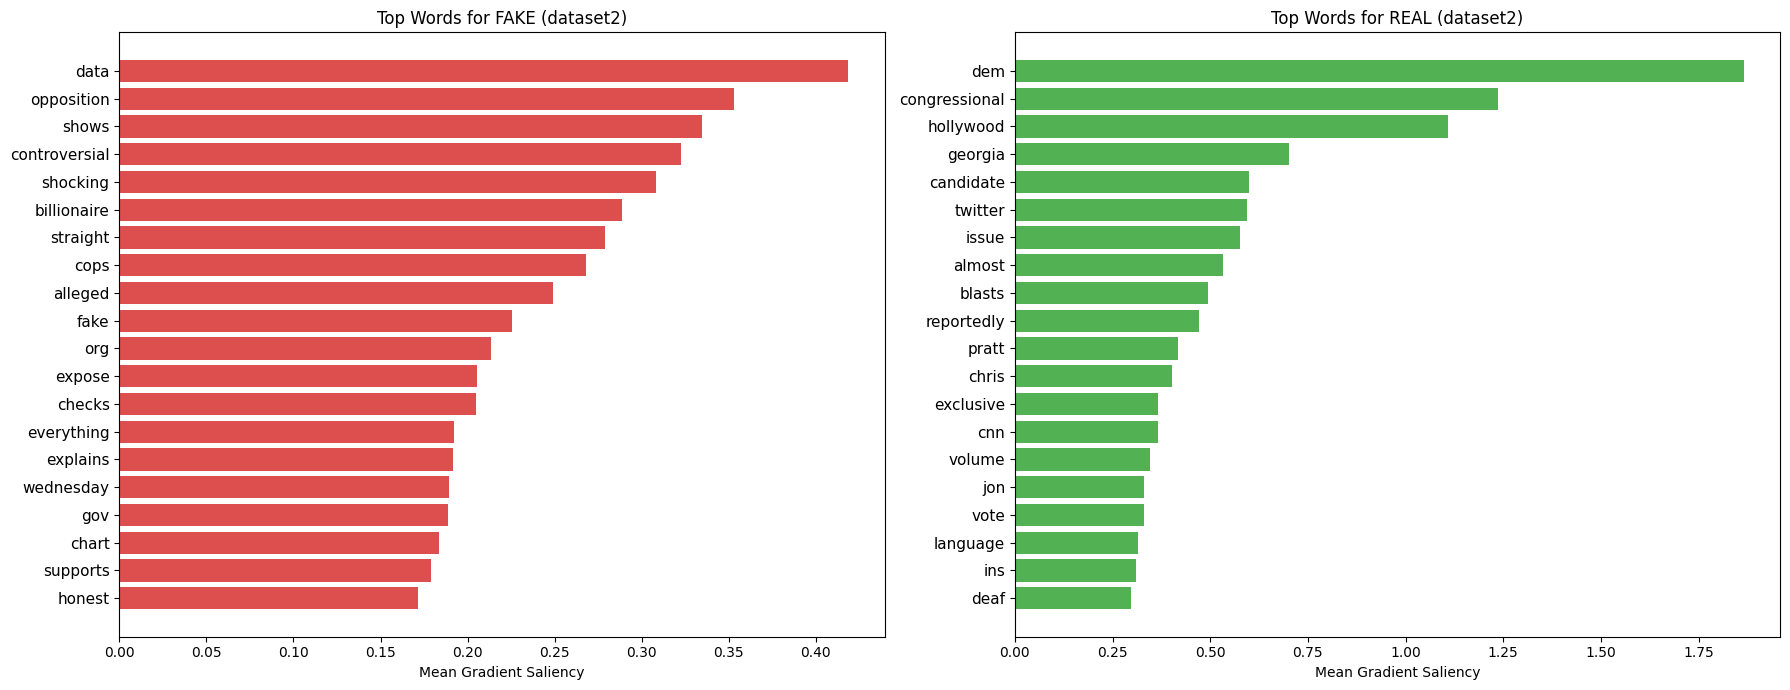

In [8]:
for ds in datasets:
    r = results[ds]
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    for ax, (word_dict, label, color) in zip(
        axes,
        [(r["fake_words"], "FAKE", "#d62728"), (r["real_words"], "REAL", "#2ca02c")]
    ):
        top = sorted(word_dict.items(), key=lambda x: -x[1])[:TOP_N_WORDS]
        if not top:
            ax.text(0.5, 0.5, "no words collected", ha="center", va="center")
            continue
        words, scores = zip(*top)
        ax.barh(range(len(words)), scores, color=color, alpha=0.82)
        ax.set_yticks(range(len(words)))
        ax.set_yticklabels(words, fontsize=11)
        ax.invert_yaxis()
        ax.set_xlabel("Mean Gradient Saliency")
        ax.set_title(f"Top Words for {label} ({ds})")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"top_words_{ds}.png", dpi=150)
    plt.show()

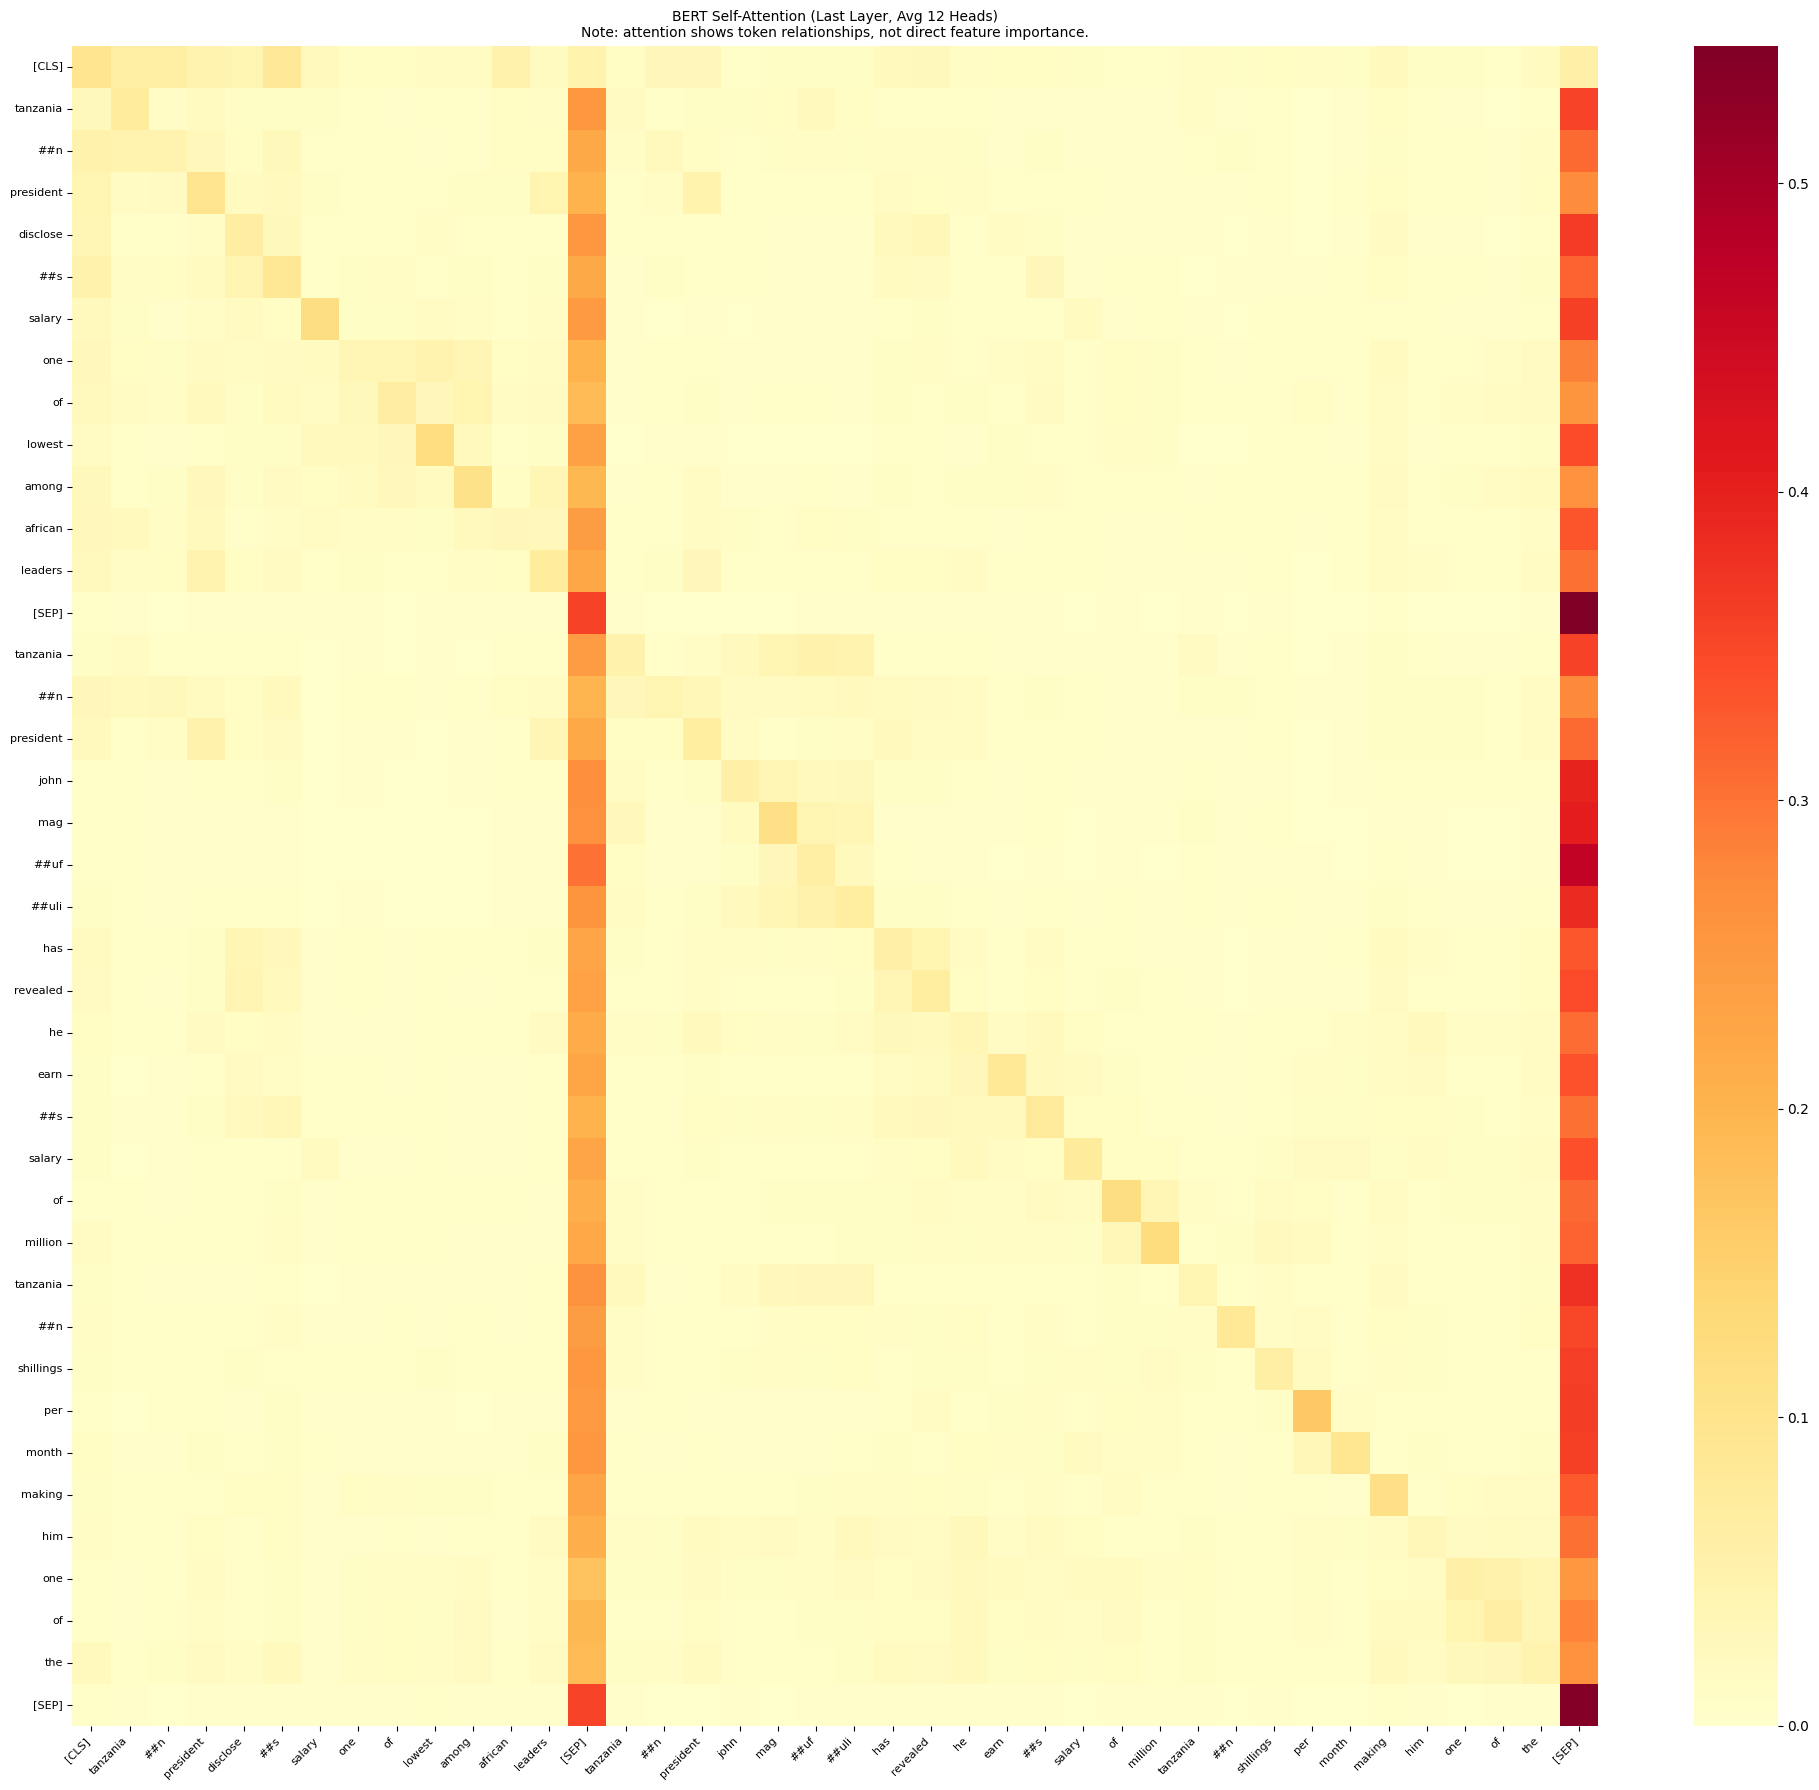

tanzanian president discloses salary one of lowest among african leaders


In [9]:
ds = datasets[0]
r = results[ds]
row = r["df"].iloc[0]

enc = r["tokenizer"](
    str(row.get("title", "")), str(row.get("text", "")),
    max_length=40, truncation=True, return_tensors="pt"
).to(r["device"])

with torch.no_grad():
    out = r["model"](**enc, output_attentions=True)

attn = out.attentions[-1][0].mean(dim=0)
tokens = r["tokenizer"].convert_ids_to_tokens(enc["input_ids"][0].cpu())
seq_len = int(enc["attention_mask"].sum().item())
tokens, attn_np = tokens[:seq_len], attn[:seq_len, :seq_len].cpu().numpy()

fig, ax = plt.subplots(figsize=(max(6, seq_len * 0.5), max(5, seq_len * 0.45)))
sns.heatmap(attn_np, xticklabels=tokens, yticklabels=tokens, cmap="YlOrRd", ax=ax, vmin=0)
ax.set_title(
    "BERT Self-Attention (Last Layer, Avg 12 Heads)\n"
    "Note: attention shows token relationships, not direct feature importance.",
    fontsize=10
)
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "attention_heatmap.png", dpi=150)
plt.show()
print(row.get("title", "")[:100])

In [10]:
all_metrics = {}

for ds in datasets:
    r = results[ds]
    report = classification_report(
        r["labels"], r["preds"], target_names=["Real", "Fake"], output_dict=True
    )
    metrics = {
        "dataset": ds,
        "n_samples_evaluated": len(r["labels"]),
        "accuracy": round(report["accuracy"], 4),
        "per_class": {
            "Real": {k: round(v, 4) for k, v in report["Real"].items()},
            "Fake": {k: round(v, 4) for k, v in report["Fake"].items()},
        },
        "confusion_matrix": confusion_matrix(r["labels"], r["preds"]).tolist(),
        "top_fake_words": [[w, round(s, 4)] for w, s in
                           sorted(r["fake_words"].items(), key=lambda x: -x[1])[:TOP_N_WORDS]],
        "top_real_words": [[w, round(s, 4)] for w, s in
                           sorted(r["real_words"].items(), key=lambda x: -x[1])[:TOP_N_WORDS]],
    }
    all_metrics[ds] = metrics
    path = FIGURES_DIR / f"metrics_{ds}.json"
    with open(path, "w") as f:
        json.dump(metrics, f, indent=2)
    print(f"saved {path.name}  (accuracy: {metrics['accuracy']:.1%})")

saved metrics_dataset1.json  (accuracy: 99.0%)
saved metrics_dataset2.json  (accuracy: 96.0%)


## LLM Explanations

In [11]:
import urllib.request
import urllib.error
import json as _json


def ask_llm(article_text, prediction, confidence, top_words, model=LLM_MODEL):
    word_list = "\n".join(f"  '{w}': {s:.4f}" for w, s in top_words[:12])
    prompt = (
        f"A BERT model classified the following news article as '{prediction}' "
        f"with {confidence:.1%} confidence.\n\n"
        f"Article:\n\"{article_text[:400]}\"\n\n"
        f"Most influential words (gradient saliency scores):\n{word_list}\n\n"
        f"Write 2-3 sentences in academic language explaining what linguistic patterns "
        f"or credibility signals the model likely detected. Focus on writing style, not "
        f"the topic. Reference specific words from the list."
    )
    payload = _json.dumps({
        "model": model,
        "messages": [{"role": "user", "content": prompt}],
        "stream": False,
    }).encode("utf-8")
    try:
        req = urllib.request.Request(
            "http://localhost:11434/api/chat",
            data=payload,
            headers={"Content-Type": "application/json"},
        )
        with urllib.request.urlopen(req, timeout=120) as resp:
            result = _json.loads(resp.read())
        return result["message"]["content"].strip()
    except urllib.error.URLError:
        print("ollama not reachable. Open the ollama app or run 'ollama serve'.")
        return None
    except Exception as e:
        print(f"LLM call failed: {e}")
        return None

In [12]:
all_explanations = []

for ds in datasets:
    r = results[ds]
    sample_rows = r["df"].sample(n=min(N_LLM_SAMPLES, len(r["df"])), random_state=7)
    print(f"\n{ds}")

    for _, row in sample_rows.iterrows():
        title = str(row.get("title", ""))
        text = str(row.get("text", ""))
        true_label = int(row["label"])

        pred, conf, word_scores = get_saliency(
            title, text, r["model"], r["tokenizer"], r["device"]
        )
        explanation = ask_llm(text, LABEL_NAMES[pred], conf, word_scores[:12])

        if explanation:
            all_explanations.append({
                "dataset": ds, "title": title,
                "true_label": LABEL_NAMES[true_label],
                "prediction": LABEL_NAMES[pred], "confidence": conf,
                "top_words": word_scores[:8], "explanation": explanation,
            })
            print(f"\n  [{LABEL_NAMES[true_label]} -> {LABEL_NAMES[pred]}] {title[:70]}")
            print(f"  words: {', '.join(w for w, _ in word_scores[:6])}")
            print(f"  {explanation}")


dataset1

  [REAL -> REAL] here how crooked hillary deleted the money trail of millions in mails
  words: crooked, deleted, here, hillary, how, trey
  The BERT model likely identified several linguistic patterns that contribute to the perceived authenticity of the text, such as the repetition of key terms like "hillary" and "here," which suggests a focused narrative about a particular individual's actions. Additionally, the inclusion of a specific name, "trey gowdy," along with the mention of a concrete action like "deleted," may have reinforced the article’s credibility by providing apparent detail and specificity. However, the reliance on terms like "crooked" might slightly undermine this, as such emotionally charged words could signal bias rather than objectivity.

  [FAKE -> FAKE] pro kurdish opposition leaders trial opens in turkey
  words: opens, kurdish, trial, turkey, kurdish, turkey
  The BERT model's classification of the article as "FAKE" with high confidence is likely infl